# Secrets of Darkwood — Gaming Product Analytics

## 1. Player Monetization Analysis

### Objective

The objective of this analysis is to evaluate player monetization in the game
*Secrets of Darkwood*.

The analysis focuses on:

- estimating the overall share of paying players;
- comparing payer conversion across character races;
- identifying character races with relatively higher or lower monetization rates.

The analysis is based on registered players and their payment status.

### 1.1 Overall Payer Share

First, we estimate the overall share of paying players among all registered
players.

A player is considered a payer if their `payer` indicator equals 1.

The metric is calculated as:

$$
\text{Payer Share} =
\frac{\text{Number of Paying Players}}
{\text{Total Number of Registered Players}}
$$

This metric provides a baseline for evaluating the overall monetization level
of the player base.

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.3f}".format)

In [29]:
overall_monetization = pd.read_csv(
    "overall_monetization.csv"
)

monetization_by_race = pd.read_csv(
    "monetization_by_race.csv"
)

In [30]:
overall_monetization

,players_total,payers_total,payer_share
0,22214,3929,0.177


The overall payer share is approximately 17.7%, meaning that fewer than one
in five registered players made at least one payment.

### 1.2 Payer Share by Character Race

Next, we compare the payer share across character races.

This analysis helps identify whether player character characteristics are
associated with differences in monetization behavior.

For each race, we calculate:

- the number of paying players;
- the total number of registered players;
- the share of paying players.

The payer share is calculated as:

$$
\text{Payer Share}_{race} =
\frac{\text{Paying Players}_{race}}
{\text{Registered Players}_{race}}
$$

The results are sorted by payer share to make differences between character
races easier to compare.

In [31]:
monetization_by_race

,race,payers_race,players_race,payer_share
0,Demon,238,1229,0.194
1,Hobbit,659,3648,0.181
2,Human,1114,6328,0.176
3,Northman,626,3562,0.176
4,Orc,636,3619,0.176
5,Angel,229,1327,0.173
6,Elf,427,2501,0.171


In [32]:
plot_data = monetization_by_race.sort_values(
    "payer_share",
    ascending=True
)

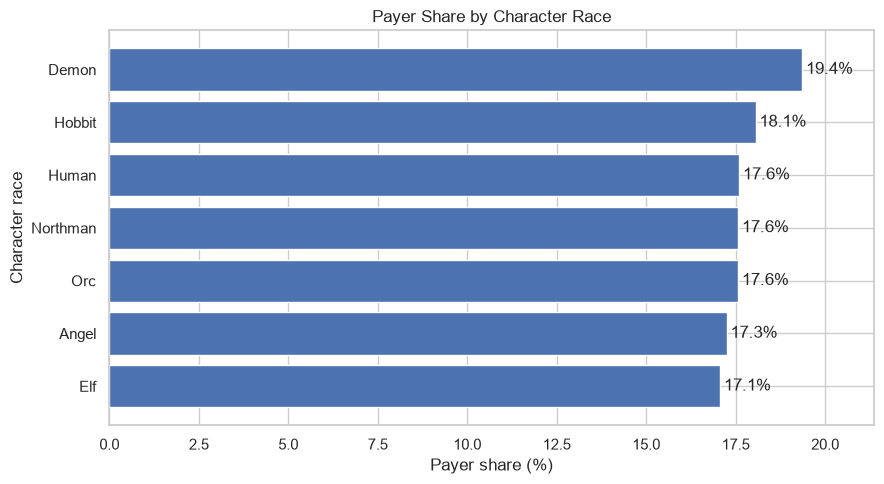

In [33]:
plt.figure(figsize=(9, 5))

plt.barh(
    plot_data["race"],
    plot_data["payer_share"] * 100
)

plt.xlabel("Payer share (%)")
plt.ylabel("Character race")
plt.title("Payer Share by Character Race")

for i, value in enumerate(
    plot_data["payer_share"] * 100
):
    plt.text(
        value + 0.1,
        i,
        f"{value:.1f}%",
        va="center"
    )

plt.xlim(
    0,
    plot_data["payer_share"].max() * 100 + 2
)

plt.tight_layout()
plt.show()

### Key Findings

- The overall payer share is approximately 17.7%, indicating that fewer than
  one in five registered players make in-game payments.

- Demon players have the highest payer share at approximately 19.4%, while
  Elf players have the lowest at approximately 17.1%.

- The difference between the highest and lowest payer shares is relatively
  small at around 2.3 percentage points, suggesting that character race alone
  is unlikely to be a strong predictor of whether a player will become a payer.

- The results indicate that monetization differences across character races
  exist, but additional player characteristics and behavioral metrics should
  be considered to better understand the factors associated with payment
  behavior.

## 2. In-Game Purchase Analysis

### Objective

The objective of this analysis is to investigate purchasing behavior inside the
game *Secrets of Darkwood*.

The analysis focuses on:

- examining the distribution of purchase amounts;
- identifying potential anomalies in transaction data;
- analyzing the popularity of in-game items;
- understanding purchasing patterns across all recorded transactions.

These insights help evaluate player spending behavior and identify potential
product issues or opportunities for monetization improvements.

### 2.1 Purchase Amount Statistics

First, we examine the overall distribution of purchase amounts.

For all recorded transactions, we calculate:

- total number of transactions;
- total transaction value;
- minimum and maximum purchase amount;
- mean purchase amount;
- median purchase amount;
- standard deviation.

Comparing the mean and the median helps identify whether the purchase amount
distribution is symmetric or heavily skewed by expensive purchases.

In [35]:
purchase_statistics = pd.read_csv("purchase_statistics.csv")

purchase_statistics

,total_transactions,total_revenue,min_purchase_amount,max_purchase_amount,avg_purchase_amount,median_purchase_amount,std_purchase_amount
0,1307678,686615040,0.000,"486,615.100",525.692,74.860,"2,517.345"


In [38]:
purchase_amounts = pd.read_csv(
    "purchase_amounts.csv"
)

purchase_amounts.head()

,amount
0,21.410
1,64.980
2,50.680
3,46.490
4,18.720


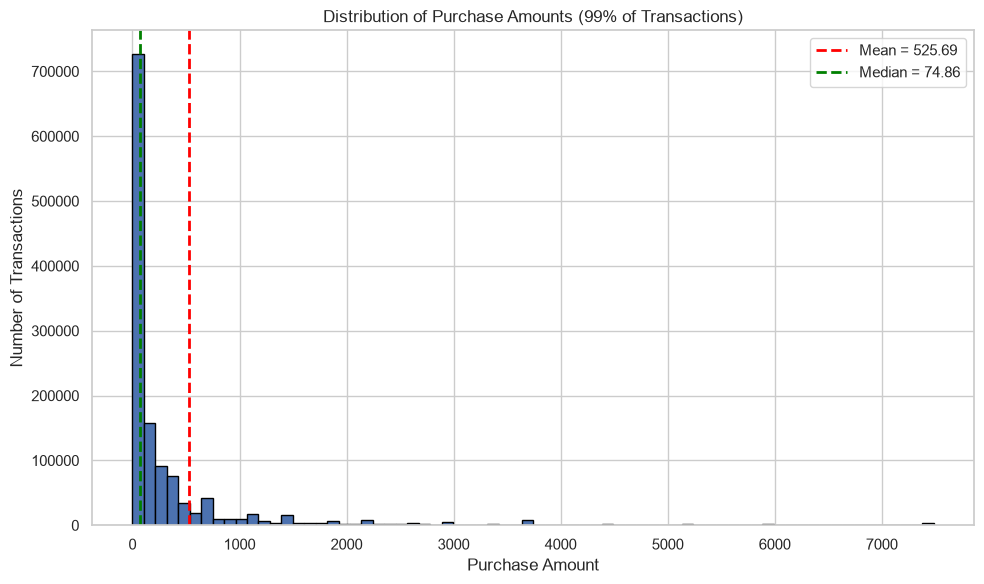

In [45]:
import matplotlib.pyplot as plt
import numpy as np

#99% of purchases
p99 = purchase_amounts["amount"].quantile(0.99)

filtered = purchase_amounts[
    purchase_amounts["amount"] <= p99
]

mean_value = purchase_statistics.loc[0, "avg_purchase_amount"]
median_value = purchase_statistics.loc[0, "median_purchase_amount"]

plt.figure(figsize=(10, 6))

plt.hist(
    filtered["amount"],
    bins=70,
    edgecolor="black"
)

plt.axvline(
    mean_value,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_value:.2f}"
)

plt.axvline(
    median_value,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_value:.2f}"
)

plt.title("Distribution of Purchase Amounts (99% of Transactions)")
plt.xlabel("Purchase Amount")
plt.ylabel("Number of Transactions")

plt.legend()

plt.tight_layout()
plt.show()

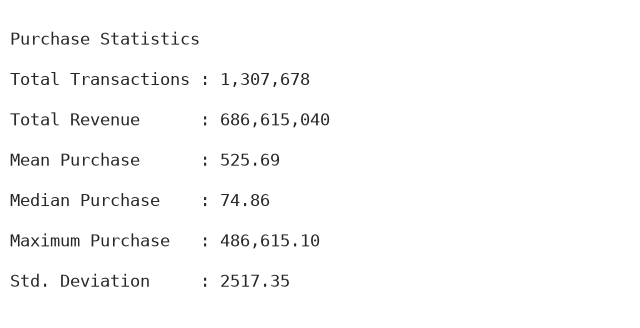

In [48]:
fig, ax = plt.subplots(figsize=(8,4))

ax.axis("off")

text = f"""
Purchase Statistics

Total Transactions : {purchase_statistics.loc[0,'total_transactions']:,}

Total Revenue      : {purchase_statistics.loc[0,'total_revenue']:,.0f}

Mean Purchase      : {purchase_statistics.loc[0,'avg_purchase_amount']:.2f}

Median Purchase    : {purchase_statistics.loc[0,'median_purchase_amount']:.2f}

Maximum Purchase   : {purchase_statistics.loc[0,'max_purchase_amount']:,.2f}

Std. Deviation     : {purchase_statistics.loc[0,'std_purchase_amount']:.2f}
"""

ax.text(
    0,
    1,
    text,
    fontsize=12,
    va="top",
    family="monospace"
)

plt.show()

The histogram illustrates the distribution of purchase amounts for the lowest
99% of transactions.

The highest 1% of purchases are excluded from the visualization to improve
readability, but they remain included in all summary statistics.

Several important observations emerge:

- the distribution is strongly right-skewed;
- most purchases have relatively low values;
- a small number of expensive purchases substantially increase the arithmetic
  mean;
- the median provides a more representative estimate of a typical purchase.

### 2.2 Zero-Cost Transactions

Next, we investigate transactions with a purchase amount equal to zero.

Although these transactions do not generate revenue, they may indicate:

- promotional giveaways;
- system-generated rewards;
- data quality issues;
- logging or processing errors.

We calculate both the absolute number of zero-cost transactions and their
share among all recorded transactions.

In [53]:
zero_cost_transactions = pd.read_csv(
    "zero_cost_transactions.csv"
)

zero_cost_transactions.style.format({
    "zero_cost_share": "{:.6f}"
})

,zero_cost_transactions,zero_cost_share
0,907,0.000694


In [51]:
zero_count = int(zero_cost_transactions.loc[0, "zero_cost_transactions"])
zero_share = zero_cost_transactions.loc[0, "zero_cost_share"] * 100

print(f"Zero-cost transactions: {zero_count:,}")
print(f"Share of all transactions: {zero_share:.4f}%")

Zero-cost transactions: 907
Share of all transactions: 0.0694%


Zero-cost transactions account for less than 0.1% of all recorded purchases.

Such transactions are therefore extremely rare and are unlikely to have a
material impact on the overall purchasing statistics.

Nevertheless, these transactions should be reviewed during data quality
checks, as they may represent promotional events, system rewards,
or data recording anomalies.

### 2.3 Most Popular Epic Items

Finally, we analyze the popularity of epic in-game items.

For each item, we calculate:

- the total number of purchase transactions;
- the share of all purchase transactions;
- the share of unique buyers who purchased the item.

This analysis helps identify which items dominate player purchases and may
represent the most successful monetization products.

In [54]:
popular_items = pd.read_csv("popular_items.csv")

popular_items.head()

,epic_item,total_transactions,transaction_share,buyer_share
0,Book of Legends,1004516,0.769,0.884
1,Bag of Holding,271875,0.208,0.868
2,Necklace of Wisdom,13828,0.011,0.118
3,Gems of Insight,3833,0.003,0.067
4,Treasure Map,3084,0.002,0.055


In [57]:
top10_items = popular_items.sort_values("total_transactions", ascending=False).head(10)

top10_items

,epic_item,total_transactions,transaction_share,buyer_share
0,Book of Legends,1004516,0.769,0.884
1,Bag of Holding,271875,0.208,0.868
2,Necklace of Wisdom,13828,0.011,0.118
3,Gems of Insight,3833,0.003,0.067
4,Treasure Map,3084,0.002,0.055
6,Amulet of Protection,1078,0.001,0.032
5,Silver Flask,795,0.001,0.046
8,Strength Elixir,580,0.000,0.024
7,Glowing Pendant,563,0.000,0.026
10,Gauntlets of Might,514,0.000,0.020


In [62]:
top10_items.style.format({
    "transaction_share": "{:.2%}",
    "buyer_share": "{:.2%}"
})

,epic_item,total_transactions,transaction_share,buyer_share
0,Book of Legends,1004516,76.87%,88.41%
1,Bag of Holding,271875,20.81%,86.77%
2,Necklace of Wisdom,13828,1.06%,11.80%
3,Gems of Insight,3833,0.29%,6.71%
4,Treasure Map,3084,0.24%,5.46%
6,Amulet of Protection,1078,0.08%,3.23%
5,Silver Flask,795,0.06%,4.59%
8,Strength Elixir,580,0.04%,2.40%
7,Glowing Pendant,563,0.04%,2.57%
10,Gauntlets of Might,514,0.04%,2.04%


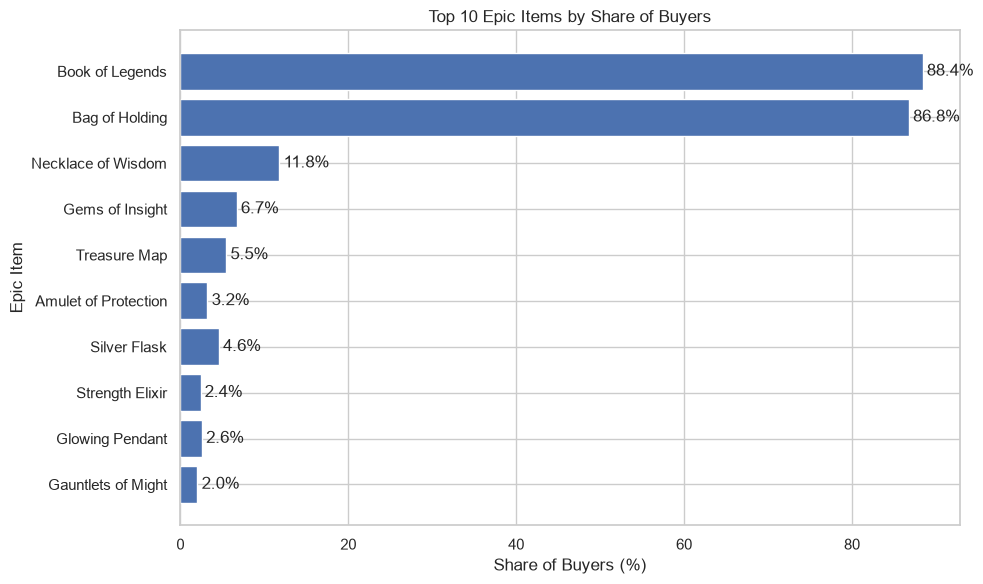

In [59]:
plt.figure(figsize=(10,6))

plt.barh(
    top10_items["epic_item"],
    top10_items["buyer_share"] * 100
)

plt.xlabel("Share of Buyers (%)")
plt.ylabel("Epic Item")
plt.title("Top 10 Epic Items by Share of Buyers")

plt.gca().invert_yaxis()

for i, value in enumerate(top10_items["buyer_share"] * 100):
    plt.text(
        value + 0.5,
        i,
        f"{value:.1f}%",
        va="center"
    )

plt.tight_layout()

plt.show()

The popularity of epic items is highly concentrated.

Two items — **Book of Legends** and **Bag of Holding** — dominate player
purchases, with both being bought by more than 85% of all purchasing players.

The remaining items have substantially smaller buyer shares, indicating a
long-tail distribution of player demand across epic items.

This suggests that only a small number of products account for the majority
of player engagement with premium content.

### Key Findings

- Purchase amounts are highly right-skewed, with a small number of expensive
  transactions substantially increasing the average purchase value.
- The median purchase amount provides a more representative estimate of a
  typical transaction than the arithmetic mean.
- Zero-cost transactions account for less than 0.1% of all purchases and are
  unlikely to affect the overall purchasing statistics.
- Player demand for epic items is highly concentrated: two products dominate
  purchases, while the remaining items form a long tail with relatively low
  buyer shares.